# Task multiclass training

Trains a single model on the 4-class task dataset (3 target species +
`non_target`). Reuses the dataset pipeline and metric helpers from
`building.scaling` (no scaling sweep, just one fit).

Metrics mirror the TinyChirp layout where applicable:
**top-1 accuracy, per-class precision/recall/F1/F2, macro-averaged versions,
one-vs-rest ROC/AUC, confusion matrix.**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os

import pyrootutils

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [3]:
COLLECTION = "task_dataset"
BUILD_MODEL = "sincnet"  # one of: mel_cnn, cnn1d, sincnet, leaf
EPOCHS = 100
PATIENCE = 15
BATCH_SIZE = 32
SEED = 42
THRESHOLD = 0.5  # only used for the multi-label-style metric helper
NON_TARGET_NAME = "non_target"
RESULTS_FILE = ROOT / "results" / f"{COLLECTION}_{BUILD_MODEL}.json"
MODEL_PATH = ROOT / "models" / COLLECTION / f"{BUILD_MODEL}_task.keras"

## Load dataset catalog

Uses the same per-class cached waveform catalog that `scaling.py` builds. The
first run populates `.cache/<collection>/waveform_<hash>/` for each split; later
runs hit the cache directly.

In [4]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel("ERROR")
logging.getLogger("absl").setLevel("ERROR")
warnings.filterwarnings("ignore", message=".*AudioResample.*")

from building.scaling import (
    _build_dataset_from_catalog,
    _collect_predictions,
    _compute_metrics,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for

catalog = load_dataset_catalog(COLLECTION)

non_target_idx = catalog.class_names.index(NON_TARGET_NAME)
target_idxs = [i for i, n in enumerate(catalog.class_names) if n != NON_TARGET_NAME]
final_labels = [catalog.class_names[i] for i in target_idxs] + [NON_TARGET_NAME]
print(f"target_idxs={target_idxs}  non_target_idx={non_target_idx}")
print(f"final label order: {final_labels}")

target_idxs=[0, 1, 2]  non_target_idx=3
final label order: ['Emberiza_calandra', 'Hippolais_polyglotta', 'Regulus_ignicapilla', 'non_target']


In [5]:
import pandas as pd

counts = pd.DataFrame(
    [(e.name, e.train.count, e.val.count, e.test.count) for e in catalog.entries],
    columns=["class", "train", "val", "test"],
).set_index("class")
counts["total"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum(axis=0)

(
    counts.style
    .background_gradient(cmap="Blues", subset=(counts.index[:-1], ["train", "val", "test"]))
    .format("{:,}")
    .set_caption(f"Sample counts per class × split  ({COLLECTION})")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "110%"), ("padding", "6px 0")]},
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])
)

,train,val,test,total
class,,,,
Emberiza_calandra,"1,820",372,417,"2,609"
Hippolais_polyglotta,"2,100",446,454,"3,000"
Regulus_ignicapilla,"2,100",450,450,"3,000"
non_target,"11,986","2,568","2,569","17,123"
TOTAL,"18,006","3,836","3,890","25,732"


## Build train/val/test pipelines

`_build_dataset_from_catalog` shuffles each class independently, repeats, and
mixes via `sample_from_datasets` so every training batch is class-balanced
regardless of class size. Validation/test use the natural distribution.

In [6]:
input_repr = input_repr_for(BUILD_MODEL)
rng = np.random.default_rng(SEED)

train_ds, meta = _build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="train", input_repr=input_repr, augment=True,
)
val_ds, _ = _build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="val", input_repr=input_repr, augment=False,
)
test_ds, _ = _build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="test", input_repr=input_repr, augment=False,
)
print(f"n_classes={meta.n_classes}  epoch_samples={meta.epoch_samples}")
print("class_weights:")
for lbl, w in meta.class_weights.items():
    print(f"  {final_labels[lbl]:<24s} {w:.3f}")

n_classes=4  epoch_samples=18006
class_weights:
  Emberiza_calandra        1.386
  Hippolais_polyglotta     1.202
  Regulus_ignicapilla      1.202
  non_target               0.211


## Build model and train

In [7]:
tf.keras.backend.clear_session()
model = model_factory(BUILD_MODEL)(meta.n_classes)
model.summary()

Model: "sincnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio (InputLayer)              │ (None, 48000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_nhwc (Reshape)               │ (None, 48000, 1, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sincnet_convolution             │ (None, 2996, 1, 32)    │            64 │
│ (SincnetConv)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 2996, 1, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ envelope_pool                   │ (None, 749, 1, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_1 (Conv2D)        │ (None, 375, 1, 16)     │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 375, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool_1                 │ (None, 93, 1, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv2D)        │ (None, 47, 1, 16)      │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 47, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_pool (AveragePooling2D)   │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,588 (29.64 KB)

 Trainable params: 7,588 (29.64 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ],
)
print(f"Stopped after {len(history.history['loss'])} epochs")

Epoch 1/100


I0000 00:00:1778681480.841481 1255192 service.cc:145] XLA service 0x7172c8005800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778681480.841527 1255192 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1778681483.496231 1255192 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


563/563 - 37s - 65ms/step - accuracy: 0.5919 - loss: 0.2311 - precision: 0.7810 - recall: 0.4031 - val_accuracy: 0.7070 - val_loss: 0.1595 - val_precision: 0.7570 - val_recall: 0.6666
Epoch 2/100
563/563 - 32s - 57ms/step - accuracy: 0.6576 - loss: 0.1562 - precision: 0.7017 - recall: 0.6210 - val_accuracy: 0.6767 - val_loss: 0.1467 - val_precision: 0.7405 - val_recall: 0.6361
Epoch 3/100
563/563 - 29s - 52ms/step - accuracy: 0.6718 - loss: 0.1436 - precision: 0.7087 - recall: 0.6392 - val_accuracy: 0.7106 - val_loss: 0.1460 - val_precision: 0.7670 - val_recall: 0.6564
Epoch 4/100
563/563 - 29s - 52ms/step - accuracy: 0.6836 - loss: 0.1374 - precision: 0.7201 - recall: 0.6523 - val_accuracy: 0.7255 - val_loss: 0.1369 - val_precision: 0.7729 - val_recall: 0.6877
Epoch 5/100
563/563 - 25s - 45ms/step - accuracy: 0.6866 - loss: 0.1345 - precision: 0.7162 - recall: 0.6566 - val_accuracy: 0.7297 - val_loss: 0.1358 - val_precision: 0.7738 - val_recall: 0.6874
Epoch 6/100
563/563 - 25s - 45ms

## Training curves

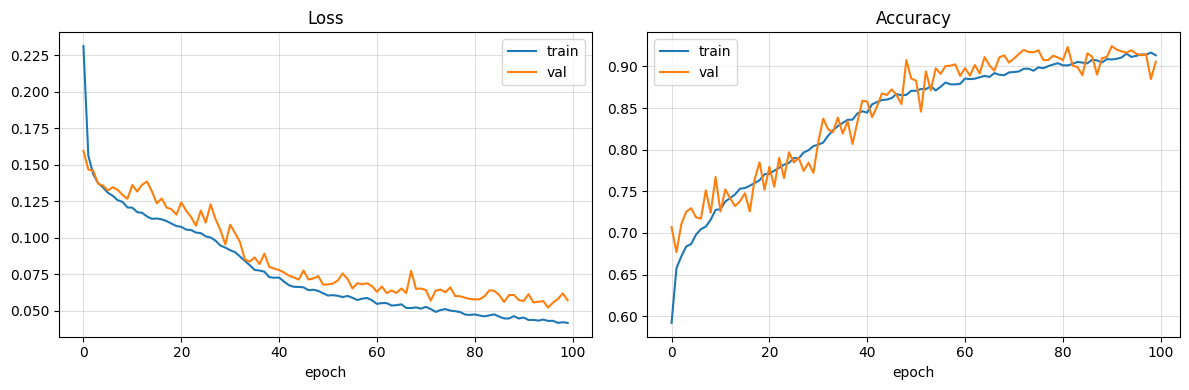

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.4)

acc_key = next(
    (k for k in ("accuracy", "categorical_accuracy") if k in history.history),
    None,
)
if acc_key is not None:
    axes[1].plot(history.history[acc_key], label="train")
    axes[1].plot(history.history[f"val_{acc_key}"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Evaluate on test set

`_compute_metrics` returns the multi-label-style macro metrics that
`scaling.py` uses (per-class precision/recall at `THRESHOLD`, then averaged).
We also compute per-class metrics via `argmax` to get the same numbers
TinyChirp's binary metrics show, generalised to multiclass.

In [10]:
test_loss = float(model.evaluate(test_ds, verbose=0)[0])
y_true, y_pred = _collect_predictions(model, test_ds)
print(f"y_true {y_true.shape}  y_pred {y_pred.shape}  test_loss={test_loss:.4f}")

m = _compute_metrics(y_true, y_pred, THRESHOLD, test_loss)
print()
print(f"Macro recall    @ thr={THRESHOLD}: {m.recall_mean:.4f}  ± {m.recall_std:.4f}")
print(f"Macro precision @ thr={THRESHOLD}: {m.precision_mean:.4f}  ± {m.precision_std:.4f}")
print(f"Macro F1        @ thr={THRESHOLD}: {m.f1_mean:.4f}  ± {m.f1_std:.4f}")
print(f"Top-1 accuracy           : {m.top1_accuracy:.4f}")

y_true (3890, 4)  y_pred (3890, 4)  test_loss=0.1006

Macro recall    @ thr=0.5: 0.9350  ± 0.0195
Macro precision @ thr=0.5: 0.8816  ± 0.0590
Macro F1        @ thr=0.5: 0.9059  ± 0.0212
Top-1 accuracy           : 0.9275


## Per-class table (argmax decisions)

Top-1 (argmax) is the natural decision rule for a multiclass softmax. The
columns are precision, recall, F1, F2 — F2 weights recall heavier, which
matches the TinyChirp convention.

In [11]:
y_true_label = np.argmax(y_true, axis=1)
y_pred_label = np.argmax(y_pred, axis=1)

precisions, recalls, f1s, f2s, supports = [], [], [], [], []
print(f"{'class':<28s} {'support':>7s} {'prec':>6s} {'rec':>6s} {'f1':>6s} {'f2':>6s}")
print("-" * 66)
for c, name in enumerate(final_labels):
    tp = int(((y_true_label == c) & (y_pred_label == c)).sum())
    fp = int(((y_true_label != c) & (y_pred_label == c)).sum())
    fn = int(((y_true_label == c) & (y_pred_label != c)).sum())
    support = int((y_true_label == c).sum())
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
    f2 = (5 * prec * rec / (4 * prec + rec)) if (4 * prec + rec) else 0.0
    precisions.append(prec); recalls.append(rec); f1s.append(f1); f2s.append(f2)
    supports.append(support)
    print(f"{name:<28s} {support:>7d} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f} {f2:>6.3f}")
print("-" * 66)
print(
    f"{'macro':<28s} {sum(supports):>7d} "
    f"{np.mean(precisions):>6.3f} {np.mean(recalls):>6.3f} "
    f"{np.mean(f1s):>6.3f} {np.mean(f2s):>6.3f}"
)
top1 = float((y_true_label == y_pred_label).mean())
print(f"\nTop-1 accuracy: {top1:.4f}")

class                        support   prec    rec     f1     f2
------------------------------------------------------------------
Emberiza_calandra                417  0.852  0.952  0.899  0.930
Hippolais_polyglotta             454  0.839  0.949  0.890  0.925
Regulus_ignicapilla              450  0.845  0.960  0.899  0.935
non_target                      2569  0.979  0.914  0.945  0.926
------------------------------------------------------------------
macro                           3890  0.879  0.944  0.909  0.929

Top-1 accuracy: 0.9275


## Confusion matrix

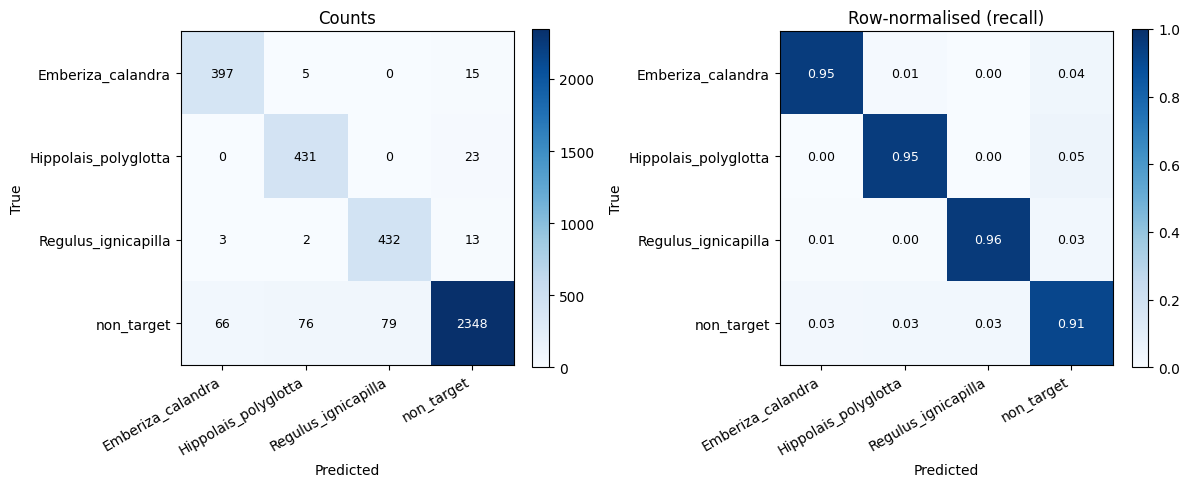

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_label, y_pred_label, labels=list(range(len(final_labels))))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt in [
    (axes[0], cm, "Counts", "d"),
    (axes[1], cm_norm, "Row-normalised (recall)", ".2f"),
]:
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=mat.max() if title == "Counts" else 1.0)
    ax.set_xticks(range(len(final_labels)))
    ax.set_xticklabels(final_labels, rotation=30, ha="right")
    ax.set_yticks(range(len(final_labels)))
    ax.set_yticklabels(final_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    thresh = mat.max() / 2.0 if title == "Counts" else 0.5
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(
                j, i, format(mat[i, j], fmt),
                ha="center", va="center",
                color="white" if mat[i, j] > thresh else "black",
                fontsize=9,
            )
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## One-vs-rest ROC and AUC

For each class we compute ROC against "all the others" and report macro AUC.
This is the multiclass analogue of TinyChirp's binary ROC.

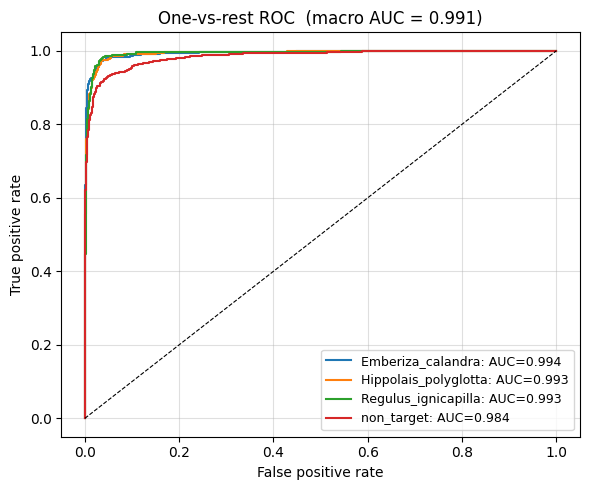

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

aucs: list[float] = []
fig, ax = plt.subplots(figsize=(6, 5))
for c, name in enumerate(final_labels):
    try:
        auc = roc_auc_score(y_true[:, c], y_pred[:, c])
        fpr, tpr, _ = roc_curve(y_true[:, c], y_pred[:, c])
    except ValueError as e:
        print(f"skipping {name}: {e}")
        continue
    aucs.append(auc)
    ax.plot(fpr, tpr, label=f"{name}: AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xscale("log")
ax.set_title(f"One-vs-rest ROC  (macro AUC = {np.mean(aucs):.3f})")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Save model and results record

In [14]:
import json
from datetime import datetime, timezone

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
model.save(MODEL_PATH)
print(f"Saved model: {MODEL_PATH}")

record = {
    "collection": COLLECTION,
    "build_model": BUILD_MODEL,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "epochs_trained": len(history.history["loss"]),
    "class_names": final_labels,
    "test_loss": test_loss,
    "top1_accuracy": top1,
    "macro": {
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
        "f1": float(np.mean(f1s)),
        "f2": float(np.mean(f2s)),
        "auc_ovr": float(np.mean(aucs)) if aucs else None,
    },
    "per_class": {
        name: {
            "support": supports[i],
            "precision": float(precisions[i]),
            "recall": float(recalls[i]),
            "f1": float(f1s[i]),
            "f2": float(f2s[i]),
            "auc_ovr": float(aucs[i]) if i < len(aucs) else None,
        }
        for i, name in enumerate(final_labels)
    },
    "confusion_matrix": cm.tolist(),
    "hyperparams": {
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "threshold": THRESHOLD,
        "input_repr": input_repr,
    },
}
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
RESULTS_FILE.write_text(json.dumps(record, indent=2))
print(f"Wrote: {RESULTS_FILE}")

Saved model: /home/nathan/Documents/multi-chirp/models/task_dataset/sincnet_task.keras
Wrote: /home/nathan/Documents/multi-chirp/results/task_dataset_sincnet.json


In [15]:
from building.scaling import cleanup_waveform_cache

# Wipe the waveform cache: reclaims a few GB and forces the next run to
# rebuild from disk so any dataset edits are picked up automatically.
cleanup_waveform_cache(COLLECTION)

[cleanup] removed /home/nathan/Documents/multi-chirp/.cache/task_dataset (9,869.5 MB freed)
